In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 贝叶斯滤波器 · 1D走廊定位
#
# 场景：5格走廊，格子0/2/4是门
# 状态：belief[i] = 机器人在格子i的概率

# 1. 定义地图：True=门，False=非门
import numpy as np
import matplotlib.pyplot as plt

# 解决 Mac 下 Matplotlib 中文显示变方块的问题
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS'] # Mac 默认中文字体
plt.rcParams['axes.unicode_minus'] = False # 正常显示负号

# 下面是你原来的代码...
corridor = np.array([True, False, True, False, True])
n = len(corridor)  # 5个格子

# 2. 初始belief：一开始完全不知道在哪，所以是均匀分布
belief = np.ones(n) / n
print("初始belief:", belief)        
print("概率和:", belief.sum())      # 确认归一化，必须是1.0

# 3. 运动模型参数 (预测步用)
p_correct = 0.9   # 成功向右移一格的概率
p_stay    = 0.1   # 留在原地的概率

# 4. 观测模型参数 (更新步用)
p_hit  = 0.8   # 是门时，传感器正确报告"是门"的概率
p_miss = 0.2   # 不是门时，传感器误报"是门"的概率

初始belief: [0.2 0.2 0.2 0.2 0.2]
概率和: 1.0


In [3]:
def predict(belief, p_correct, p_stay):
    """预测步（含边界修复）"""
    n = len(belief)
    belief_bar = np.zeros(n) 
    
    for i in range(n):
        from_left  = belief[i-1] * p_correct if i > 0 else 0
        from_here  = belief[i]   * p_stay
        belief_bar[i] = from_left + from_here
        
    # 撞墙补丁：如果在最右侧向右走，会被墙挡住，这部分概率叠加回原地
    belief_bar[-1] += belief[-1] * p_correct
    
    return belief_bar

belief_bar = predict(belief, p_correct, p_stay)
print("修复边界后向右移动一步的预测概率:", np.round(belief_bar, 3))
print("新的概率和:", belief_bar.sum())

修复边界后向右移动一步的预测概率: [0.02 0.2  0.2  0.2  0.38]
新的概率和: 1.0


In [4]:
def update(belief_bar, observation, corridor, p_hit, p_miss):
    """更新步：结合地图和传感器观测，修正概率分布"""
    n = len(belief_bar)
    belief = np.zeros(n)
    
    for i in range(n):
        # 核心逻辑：计算如果机器人在当前格子，看到这个观测值的“似然度”
        if observation == True:   # 传感器报告"是门"
            likelihood = p_hit if corridor[i] else p_miss
        else:                     # 传感器报告"不是门"
            likelihood = (1 - p_hit) if corridor[i] else (1 - p_miss)
        
        # 贝叶斯公式的核心：后验 = 似然 * 先验 (这里的先验就是预测出来的 belief_bar)
        belief[i] = likelihood * belief_bar[i]
    
    # 归一化，让总和重新回到1
    belief = belief / belief.sum()
    return belief

# 测试：传入预测结果 belief_bar，以及观测值 True ("是门")
belief_after_update = update(belief_bar, True, corridor, p_hit, p_miss)
print("观测到门后的概率:", np.round(belief_after_update, 3))

观测到门后的概率: [0.029 0.071 0.286 0.071 0.543]


=== Step 0: 初始状态 ===


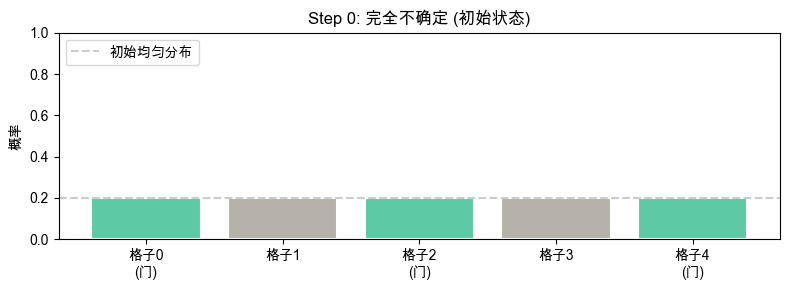

=== Step 1: 向右移动一次 (预测) ===


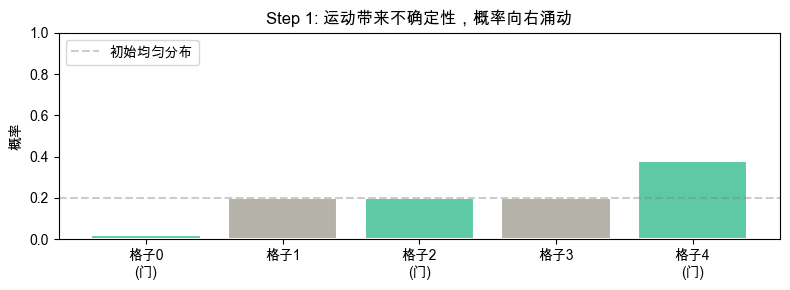

=== Step 2: 看到门 (更新) ===


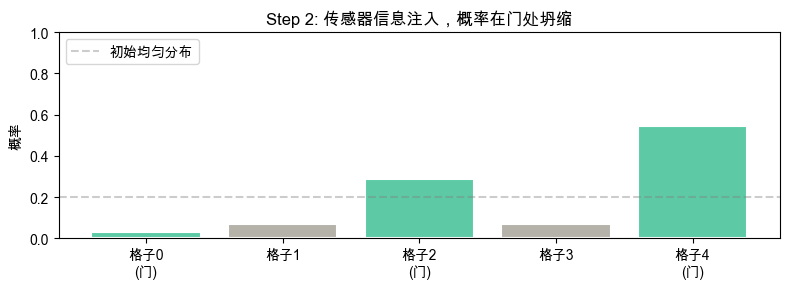

In [7]:
def plot_belief(belief, corridor, title=""):
    """把走廊地图和机器人的概率分布画出来"""
    fig, ax = plt.subplots(figsize=(8, 3))
    x = np.arange(len(belief))
    
    # 画图配色：是门的地方用绿色，不是门的地方用灰色
    colors = ['#5DCAA5' if d else '#B4B2A9' for d in corridor]
    bars = ax.bar(x, belief, color=colors, edgecolor='white', linewidth=1.5)
    
    # 设置图表样式
    ax.set_xticks(x)
    ax.set_xticklabels([f"格子{i}\n{'(门)' if corridor[i] else ''}" for i in x])
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("概率")
    ax.set_title(title)
    
    # 画一条 0.2 的基准线，对比初始状态
    ax.axhline(y=0.2, color='gray', linestyle='--', alpha=0.4, label='初始均匀分布')
    ax.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

# 我们把初始状态、预测状态、更新状态连起来看！
print("=== Step 0: 初始状态 ===")
belief_0 = np.ones(n) / n
plot_belief(belief_0, corridor, "Step 0: 完全不确定 (初始状态)")

print("=== Step 1: 向右移动一次 (预测) ===")
belief_1 = predict(belief_0, p_correct, p_stay)
plot_belief(belief_1, corridor, "Step 1: 运动带来不确定性，概率向右涌动")

print("=== Step 2: 看到门 (更新) ===")
belief_2 = update(belief_1, True, corridor, p_hit, p_miss)
plot_belief(belief_2, corridor, "Step 2: 传感器信息注入，概率在门处坍缩")